# Data collection

## Import dataset from Kaggle
    Sign Language MNIST
    ASL Alphabet

In [1]:
#!pip install kagglehub

> MNIST



In [2]:
import kagglehub

# Download the latest version of the dataset
path = kagglehub.dataset_download("datamunge/sign-language-mnist")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\User\.cache\kagglehub\datasets\datamunge\sign-language-mnist\versions\1


## Load libraries

In [3]:
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical
import os
from sklearn.model_selection import train_test_split

## Step 1 — Load the Data & Explore

In [4]:
train_df = pd.read_csv("kaggle/input/sign-language-mnist/sign_mnist_train.csv")
test_df = pd.read_csv("kaggle/input/sign-language-mnist/sign_mnist_test.csv")

In [5]:
#explore data
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)


Train shape: (27455, 785)
Test shape: (7172, 785)


In [6]:
print('== train data == \n',train_df.head())
print('\n== test data ==\n',test_df.head())

== train data == 
    label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0      3     107     118     127     134     139     143     146     150   
1      6     155     157     156     156     156     157     156     158   
2      2     187     188     188     187     187     186     187     188   
3      2     211     211     212     212     211     210     211     210   
4     13     164     167     170     172     176     179     180     184   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0     153  ...       207       207       207       207       206       206   
1     158  ...        69       149       128        87        94       163   
2     187  ...       202       201       200       199       198       199   
3     210  ...       235       234       233       231       230       226   
4     185  ...        92       105       105       108       133       163   

   pixel781  pixel782  pixel783  pixel784  
0       206

In [7]:
# check for missing values or duplicates on train
print("Train Missing values:", train_df.isnull().sum().sum())
print("Duplicates:", train_df.duplicated().sum())

# check for missing values or duplicates on test
print("Test Missing values:", test_df.isnull().sum().sum())
print("Duplicates:", test_df.duplicated().sum())

Train Missing values: 0
Duplicates: 0
Test Missing values: 0
Duplicates: 0


## Step 2 — Convert CSV to Image Files

In [8]:
def row_to_image(row):
    """Convert a row (pandas Series) into a 28x28 numpy image."""
    pixels = row.drop('label').values
    return pixels.reshape(28, 28)

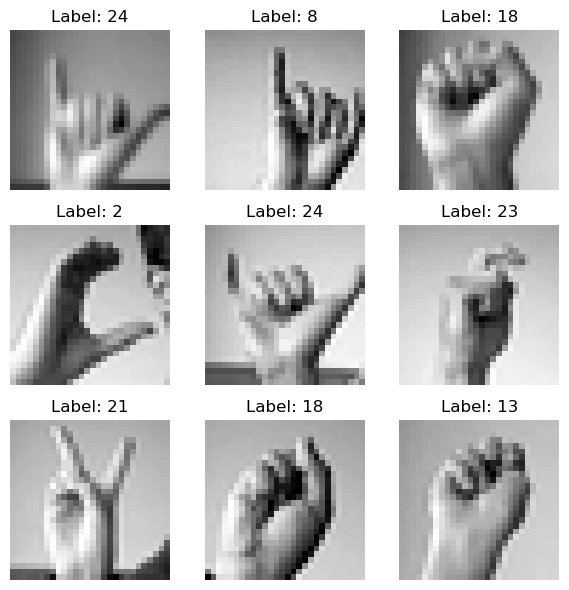

In [9]:
import matplotlib.pyplot as plt

# Pick 9 random samples
sample_df = train_df.sample(9, random_state=42)

plt.figure(figsize=(6, 6))
for i, (_, row) in enumerate(sample_df.iterrows()):
    img = row_to_image(row)
    label = row['label']
    plt.subplot(3, 3, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(f"Label: {label}")
    plt.axis("off")
plt.tight_layout()
plt.show()

# Load Images from Folders

In [10]:
label_map = {
    0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E',
    5: 'F', 6: 'G', 7: 'H', 8: 'I', 10: 'K',
    11: 'L', 12: 'M', 13: 'N', 14: 'O', 15: 'P',
    16: 'Q', 17: 'R', 18: 'S', 19: 'T', 20: 'U',
    21: 'V', 22: 'W', 23: 'X', 24: 'Y',
    25: 'del', 26: 'nothing', 27: 'space'
}

# Preprocess train data

In [11]:
# Vectorized extraction of X and y
X = train_df.drop("label", axis=1).values.reshape(-1, 28, 28).astype(np.float32)
y = train_df["label"].map(label_map).values  # convert numeric → letter

In [12]:
print("X dtype before normalization:", X.dtype)

X dtype before normalization: float32


## Normalize + Train/Validation Split

In [13]:
# 2️⃣ Normalize only if needed
if X.max() > 1.0:
    X = X.astype(np.float32) / 255.0
else:
    X = X.astype(np.float32)  # just ensure float32 type

print("\nAfter normalization:")
print(f"X dtype: {X.dtype}, min: {X.min()}, max: {X.max()}")


After normalization:
X dtype: float32, min: 0.0, max: 1.0


# Preprocess test data

In [14]:
X_test = test_df.drop("label", axis=1).values.reshape(-1, 28, 28).astype(np.float32)
y_test = test_df["label"].map(label_map).values  # convert numeric -> letter

In [15]:
# Normalize
if X_test.max() > 1.0:
    X_test /= 255.0

In [16]:
print(f"✅ MNIST Test loaded: {X_test.shape}, Labels: {len(np.unique(y_test))}")
print(f"Pixel range: {X_test.min()} - {X_test.max()}")

✅ MNIST Test loaded: (7172, 28, 28), Labels: 24
Pixel range: 0.0 - 1.0


______________________________________________________________________________
# Second data
> ASL alphapet



In [17]:

# 1️⃣ Download ASL Alphabet dataset
asl_path = kagglehub.dataset_download("grassknoted/asl-alphabet")
print("Path to ASL dataset files:", asl_path)

Path to ASL dataset files: C:\Users\User\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1


In [18]:
asl_train_dir = "/root/.cache/kagglehub/datasets/grassknoted/asl-alphabet/versions/1/asl_alphabet_train/asl_alphabet_train"

In [19]:
# جمع كل أسماء الفولدرات (A..Y)
classes_asl = sorted([d for d in os.listdir(os.path.join(asl_path, 'asl_alphabet_train/asl_alphabet_train')) if os.path.isdir(os.path.join(asl_path, 'asl_alphabet_train/asl_alphabet_train', d))])
# إزالة الـ dynamic signs J,Z
classes_asl = [cls for cls in classes_asl if cls not in ["J", "Z"]]

X_asl, y_asl = [], []

for cls in classes_asl:
    folder = os.path.join(asl_path, 'asl_alphabet_train/asl_alphabet_train', cls)
    for file in os.listdir(folder):
        img_path = os.path.join(folder, file)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        # Resize to 28x28 like MNIST
        img = cv2.resize(img, (28, 28))
        X_asl.append(img)
        y_asl.append(cls)

X_asl = np.array(X_asl, dtype=np.float32)

In [20]:
# Normalize
if X_asl.max() > 1.0:
    X_asl /= 255.0

In [21]:
# Reshape to 4D for CNN
X_asl = X_asl.reshape(-1, 28, 28, 1)
y_asl = np.array(y_asl)

print(f"✅ ASL Loaded: {X_asl.shape}, Labels: {len(np.unique(y_asl))}")
print("Pixel range:", X_asl.min(), "-", X_asl.max())

✅ ASL Loaded: (81000, 28, 28, 1), Labels: 27
Pixel range: 0.0 - 1.0


In [22]:
# 3️⃣ Sanity Check before Merge
# =========================

print(f"MNIST: {X.shape}, Labels: {len(np.unique(y))}, Classes: {sorted(np.unique(y))[:5]} ...")
print(f"ASL:   {X_asl.shape}, Labels: {len(np.unique(y_asl))}, Classes: {sorted(np.unique(y_asl))[:5]} ...")

print(f"MNIST Pixel range: {X.min()} - {X.max()}")
print(f"ASL   Pixel range: {X_asl.min()} - {X_asl.max()}")

MNIST: (27455, 28, 28), Labels: 24, Classes: ['A', 'B', 'C', 'D', 'E'] ...
ASL:   (81000, 28, 28, 1), Labels: 27, Classes: [np.str_('A'), np.str_('B'), np.str_('C'), np.str_('D'), np.str_('E')] ...
MNIST Pixel range: 0.0 - 1.0
ASL   Pixel range: 0.0 - 1.0


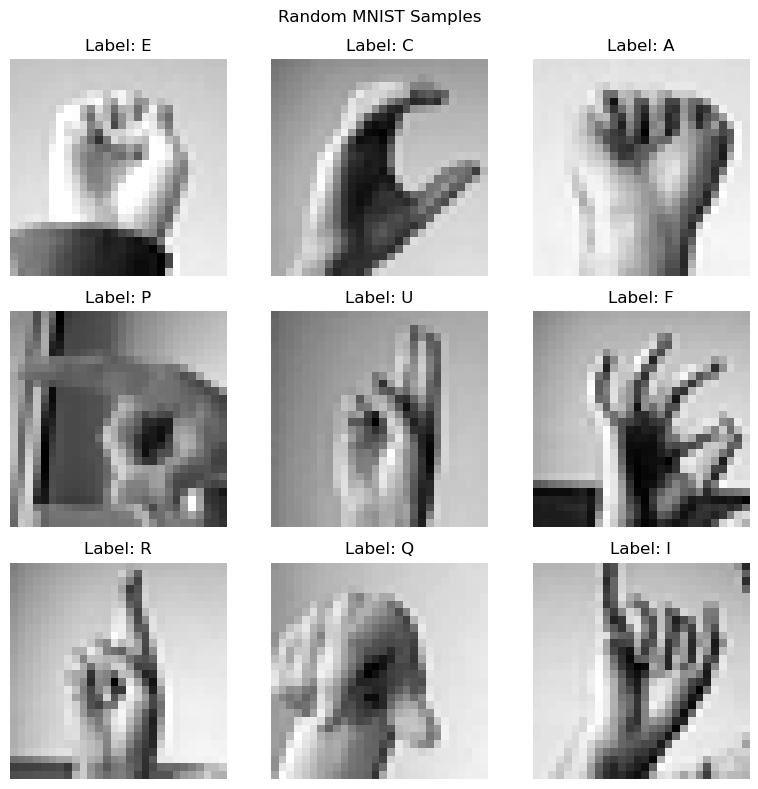

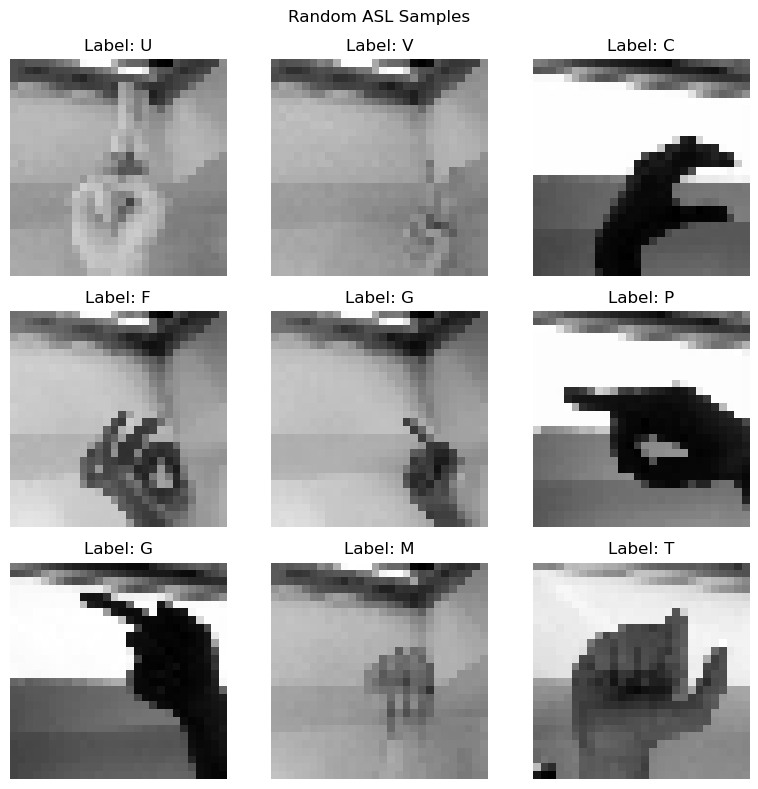

In [23]:
# Visualize few samples from MNIST
def visualize_samples(X, y, title, n=9):
    idxs = np.random.choice(len(X), n, replace=False)
    plt.figure(figsize=(8, 8))
    for i, idx in enumerate(idxs):
        plt.subplot(3, 3, i + 1)
        plt.imshow(X[idx].squeeze(), cmap="gray")
        plt.title(f"Label: {y[idx]}")
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

visualize_samples(X, y, "Random MNIST Samples", n=9)
visualize_samples(X_asl, y_asl, "Random ASL Samples", n=9)

# Merging the 2 datasets

In [24]:
# =========================
# 4️⃣ Merge MNIST + ASL
# =========================
X_full = np.concatenate([X.reshape(-1, 28, 28, 1), X_asl], axis=0)
y_full = np.concatenate([y, y_asl], axis=0)

print(f"🔄 Combined Dataset: {X_full.shape}, Labels: {len(y_full)}")

🔄 Combined Dataset: (108455, 28, 28, 1), Labels: 108455


In [25]:
# Build final classes
all_classes = sorted(np.unique(y_full))
class_to_idx = {cls: idx for idx, cls in enumerate(all_classes)}

# Encode labels to integers
y_full_encoded = np.array([class_to_idx[lbl] for lbl in y_full])

In [26]:
# 5️⃣ Train/Val/Test Split
# =========================
X_train, X_temp, y_train_idx, y_temp_idx = train_test_split(
    X_full, y_full_encoded, test_size=0.2, stratify=y_full_encoded, random_state=42
)

X_val, X_test, y_val_idx, y_test_idx = train_test_split(
    X_temp, y_temp_idx, test_size=0.5, stratify=y_temp_idx, random_state=42
)

In [27]:
# 6️⃣ One-hot Encoding
# =========================
num_classes = len(all_classes)
y_train = to_categorical(y_train_idx, num_classes=num_classes)
y_val = to_categorical(y_val_idx, num_classes=num_classes)
y_test = to_categorical(y_test_idx, num_classes=num_classes)

print(f"✅ Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}, Classes: {num_classes}")

✅ Train: (86764, 28, 28, 1), Val: (10845, 28, 28, 1), Test: (10846, 28, 28, 1), Classes: 27


# Step 3: Data Augmentation Pipeline

In [28]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
print("✅ TensorFlow ImageDataGenerator is available and working.")

✅ TensorFlow ImageDataGenerator is available and working.


In [29]:
datagen = ImageDataGenerator(
    rotation_range=10,        # تدوير بسيط ±10 درجات
    zoom_range=0.1,          # Zoom 10%
    width_shift_range=0.1,   # إزاحة أفقية 10%
    height_shift_range=0.1,  # إزاحة عمودية 10%
    shear_range=0.1,         # Shear بزاوية 10 درجات
    horizontal_flip=False,
    vertical_flip=False,
    fill_mode='nearest'
)
# Fit generator on training data
datagen.fit(X_train)

print("✅ Augmentation pipeline fitted on training data.")

✅ Augmentation pipeline fitted on training data.


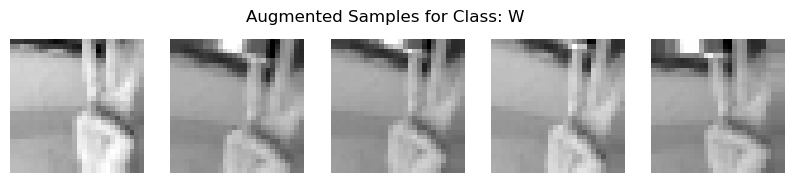

In [30]:
# 9️⃣ Visualization of Augmented Samples
sample_idx = np.random.randint(0, len(X_train))
x = X_train[sample_idx].reshape(1, 28, 28, 1)
true_label = all_classes[np.argmax(y_train[sample_idx])]

aug_iter = datagen.flow(x, batch_size=1)

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 2))
for i in range(5):
    batch = next(aug_iter)
    plt.subplot(1, 5, i + 1)
    plt.imshow(batch[0].reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.suptitle(f"Augmented Samples for Class: {true_label}")
plt.show()

# Final check

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import collections

print("🔎 FINAL DATA CHECK BEFORE TRAINING")

# 1️⃣ Shapes
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"y shapes -> Train: {y_train.shape}, Val: {y_val.shape}, Test: {y_test.shape}")
print(f"Number of Classes: {len(all_classes)}, Classes: {all_classes}")

# 2️⃣ Pixel range check
print(f"Pixel range (Train): {X_train.min()} - {X_train.max()}")
print(f"Pixel range (ASL):   {X_asl.min()} - {X_asl.max()}")

🔎 FINAL DATA CHECK BEFORE TRAINING
Train: (86764, 28, 28, 1), Val: (10845, 28, 28, 1), Test: (10846, 28, 28, 1)
y shapes -> Train: (86764, 27), Val: (10845, 27), Test: (10846, 27)
Number of Classes: 27, Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'del', 'nothing', 'space']
Pixel range (Train): 0.0 - 1.0
Pixel range (ASL):   0.0 - 1.0


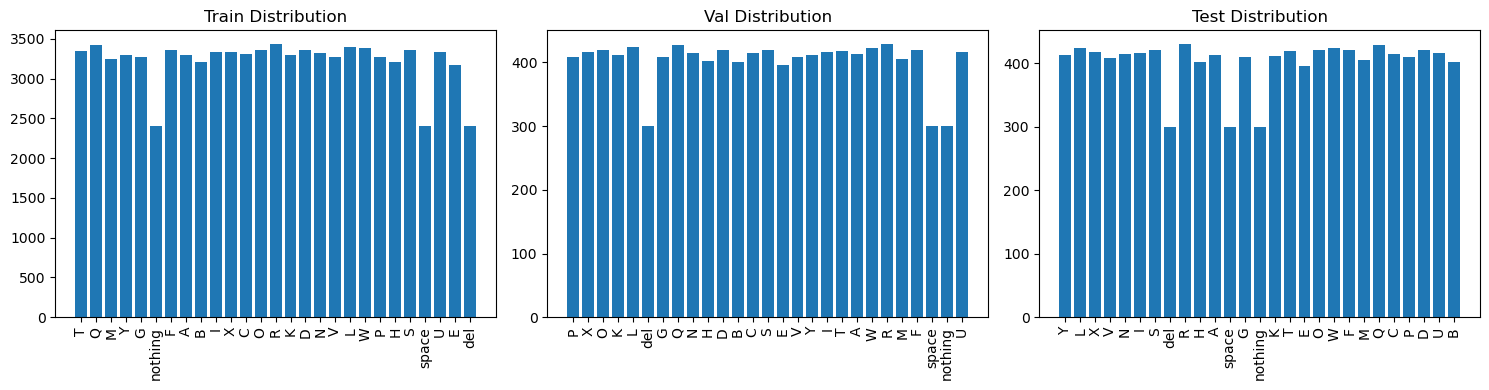

In [32]:
# 3️⃣ Class distribution check (Stratified?)
def plot_distribution(y_idx, title):
    counts = collections.Counter(y_idx)
    plt.bar([all_classes[i] for i in counts.keys()], counts.values())
    plt.title(title)
    plt.xticks(rotation=90)

plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plot_distribution(np.argmax(y_train, axis=1), "Train Distribution")

plt.subplot(1, 3, 2)
plot_distribution(np.argmax(y_val, axis=1), "Val Distribution")

plt.subplot(1, 3, 3)
plot_distribution(np.argmax(y_test, axis=1), "Test Distribution")
plt.tight_layout()
plt.show()


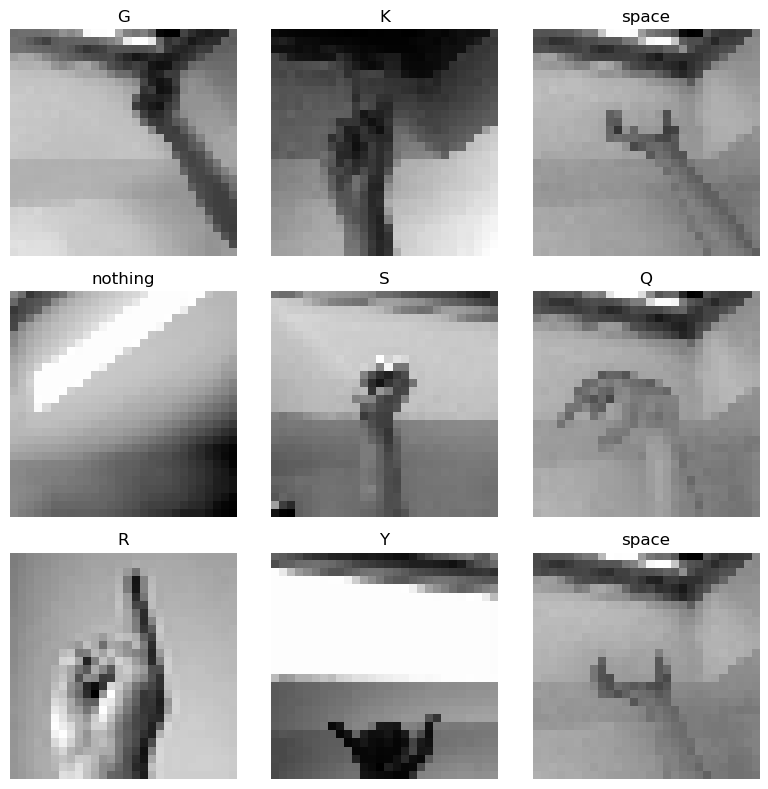

In [33]:
# 4️⃣ Sample visualization
def visualize_random_samples(X, y, classes, n=9):
    idxs = np.random.choice(len(X), n, replace=False)
    plt.figure(figsize=(8, 8))
    for i, idx in enumerate(idxs):
        plt.subplot(3, 3, i+1)
        plt.imshow(X[idx].squeeze(), cmap="gray")
        plt.title(classes[np.argmax(y[idx])])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

visualize_random_samples(X_train, y_train, all_classes, n=9)

# **Milestone 1 Finished successfully ✅**

# *LENET50*

In [54]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
import numpy as np

# Dataset info
NUM_CLASSES = 27
IMG_SHAPE = (28, 28, 1)

# Optional: check TensorFlow device
print("✅ TF Version:", tf.__version__)
print("🔧 Available devices:", tf.config.list_physical_devices())


✅ TF Version: 2.20.0
🔧 Available devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [55]:
# Convert one-hot encoded labels to integer labels if needed
if len(y_train.shape) > 1 and y_train.shape[1] == NUM_CLASSES:
    y_train = np.argmax(y_train, axis=1)
    y_val   = np.argmax(y_val, axis=1)
    y_test  = np.argmax(y_test, axis=1)

print("✅ y_train shape:", y_train.shape)


✅ y_train shape: (86764,)


In [56]:
def build_lenet50(input_shape=IMG_SHAPE, num_classes=NUM_CLASSES):
    weight_decay = 1e-4

    model = keras.Sequential([
        # Block 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                      kernel_regularizer=regularizers.l2(weight_decay),
                      input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same',
                      kernel_regularizer=regularizers.l2(weight_decay)),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 3
        layers.Conv2D(128, (3, 3), activation='relu', padding='same',
                      kernel_regularizer=regularizers.l2(weight_decay)),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.4),

        # Dense layers
        layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(weight_decay)),
        layers.BatchNormalization(),
        layers.Dropout(0.5),

        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss='sparse_categorical_crossentropy',  # We now use integer labels
        metrics=['accuracy']
    )
    return model

model = build_lenet50()
model.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 27)             │         3,483 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 114,075 (445.61 KB)

 Trainable params: 113,371 (442.86 KB)

 Non-trainable params: 704 (2.75 KB)

In [57]:
datagen = keras.preprocessing.image.ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)
datagen.fit(X_train)



In [58]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5),
    ModelCheckpoint('lenet50_best.h5', save_best_only=True, monitor='val_accuracy', mode='max')
]



In [62]:
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=128),
    validation_data=(X_val, y_val),
    epochs=20,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/20
678/678 ━━━━━━━━━━━━━━━━━━━━ 32s 47ms/step - accuracy: 0.8940 - loss: 0.3912 - val_accuracy: 0.9800 - val_loss: 0.1390 - learning_rate: 1.5625e-05
Epoch 2/20
678/678 ━━━━━━━━━━━━━━━━━━━━ 32s 47ms/step - accuracy: 0.8939 - loss: 0.3895 - val_accuracy: 0.9769 - val_loss: 0.1476 - learning_rate: 1.5625e-05
Epoch 3/20
678/678 ━━━━━━━━━━━━━━━━━━━━ 32s 48ms/step - accuracy: 0.8935 - loss: 0.3932 - val_accuracy: 0.9799 - val_loss: 0.1397 - learning_rate: 1.0000e-05
Epoch 4/20
678/678 ━━━━━━━━━━━━━━━━━━━━ 32s 48ms/step - accuracy: 0.8943 - loss: 0.3913 - val_accuracy: 0.9805 - val_loss: 0.1368 - learning_rate: 1.0000e-05


In [63]:
model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

fine_tune_history = model.fit(
    datagen.flow(X_train, y_train, batch_size=128),
    validation_data=(X_val, y_val),
    epochs=10,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/10
677/678 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.8914 - loss: 0.4026 

678/678 ━━━━━━━━━━━━━━━━━━━━ 34s 48ms/step - accuracy: 0.8927 - loss: 0.3965 - val_accuracy: 0.9834 - val_loss: 0.1310 - learning_rate: 1.0000e-04
Epoch 2/10
677/678 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.8969 - loss: 0.3849 

678/678 ━━━━━━━━━━━━━━━━━━━━ 33s 48ms/step - accuracy: 0.8955 - loss: 0.3859 - val_accuracy: 0.9840 - val_loss: 0.1247 - learning_rate: 1.0000e-04
Epoch 3/10
678/678 ━━━━━━━━━━━━━━━━━━━━ 33s 48ms/step - accuracy: 0.8926 - loss: 0.3920 - val_accuracy: 0.9781 - val_loss: 0.1396 - learning_rate: 1.0000e-04
Epoch 4/10
678/678 ━━━━━━━━━━━━━━━━━━━━ 33s 48ms/step - accuracy: 0.8975 - loss: 0.3792 - val_accuracy: 0.9775 - val_loss: 0.1418 - learning_rate: 1.0000e-04
Epoch 5/10
678/678 ━━━━━━━━━━━━━━━━━━━━ 33s 48ms/step - accuracy: 0.8977 - loss: 0.3790 - val_accuracy: 0.9796 - val_loss: 0.1361 - learning_rate: 5.0000e-05
Epoch 6/10
678/678 ━━━━━━━━━━━━━━━━━━━━ 33s 48ms/step - accuracy: 0.8963 - loss: 0.3802 - val_accuracy: 0.9791 - val_loss: 0.1356 - learning_rate: 5.0000e-05


In [64]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=1)
print(f"✅ Final Test Accuracy: {test_acc*100:.2f}%")
print(f"📉 Final Test Loss: {test_loss:.4f}")


339/339 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9844 - loss: 0.1257 
✅ Final Test Accuracy: 98.44%
📉 Final Test Loss: 0.1257


In [65]:
model.save("lenet50_finetuned.h5")
print("💾 Model saved as lenet50_finetuned.h5")


💾 Model saved as lenet50_finetuned.h5


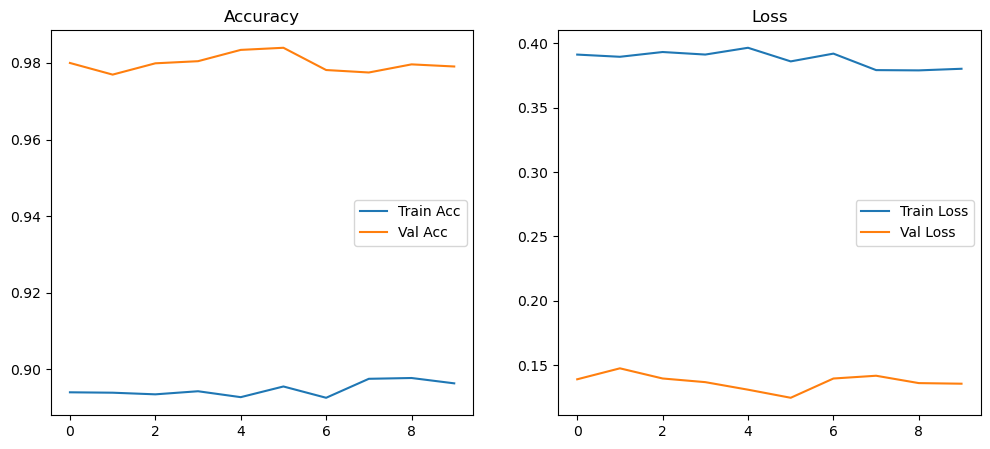

In [66]:
import matplotlib.pyplot as plt

def plot_history(h1, h2=None):
    acc = h1.history['accuracy']
    val_acc = h1.history['val_accuracy']
    loss = h1.history['loss']
    val_loss = h1.history['val_loss']

    if h2:
        acc += h2.history['accuracy']
        val_acc += h2.history['val_accuracy']
        loss += h2.history['loss']
        val_loss += h2.history['val_loss']

    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(acc, label='Train Acc')
    plt.plot(val_acc, label='Val Acc')
    plt.legend()
    plt.title('Accuracy')

    plt.subplot(1,2,2)
    plt.plot(loss, label='Train Loss')
    plt.plot(val_loss, label='Val Loss')
    plt.legend()
    plt.title('Loss')
    plt.show()

plot_history(history, fine_tune_history)
